In [1]:
#Basic libraries 
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

#Sklearn 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.metrics import mean_absolute_error,r2_score

In [2]:
#loading the dataframe 
df = pd.read_csv("Algerian_forest_fires_dataset_CLEANED.csv",index_col=0)

In [3]:
#Defining X and Y 
X = df.drop('FWI',axis=1)
y = df['FWI']

In [4]:
#Train Test Split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: >

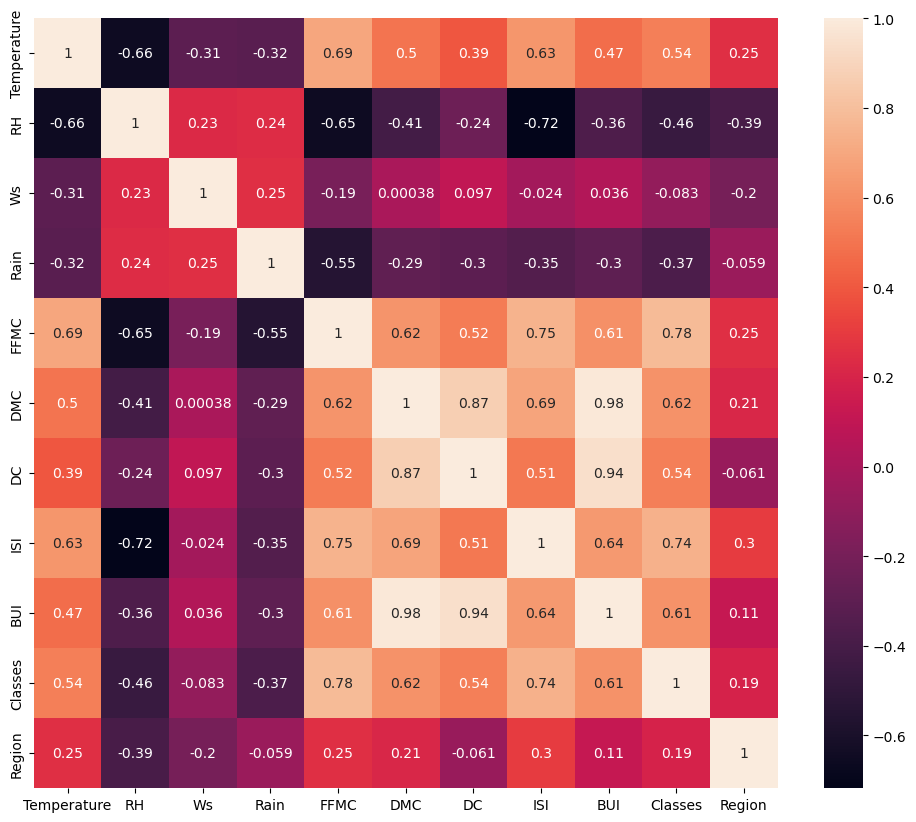

In [5]:
#Checking for multicollinearity 
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr,annot=True) 

In [6]:
def correlation(dataset,threshold):
    col_corr = set() 
    corr_matrix = dataset.corr() 
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname = corr_matrix.columns[i] 
                col_corr.add(colname) 
    return col_corr 

In [7]:
#More than 90
corr_features90 = correlation(X_train,0.90)
print("More Than 90:",corr_features90)
#More than 80 
corr_features80 = correlation(X_train,0.80)
print("More Than 80:",corr_features80)

More Than 90: {'BUI'}
More Than 80: {'DC', 'BUI'}


In [8]:
#Droping more than 90 features 
X_train.drop(corr_features90,axis=1,inplace=True)
X_test.drop(corr_features90,axis=1,inplace=True)

<Axes: >

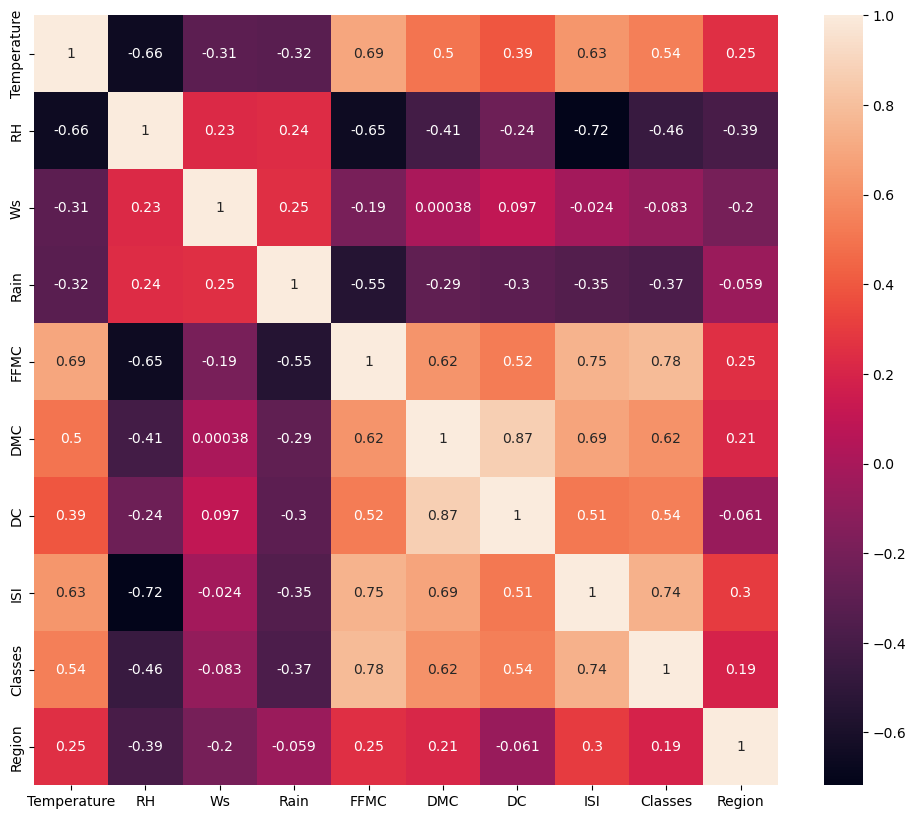

In [9]:
#Now Checking for multicollinearity 
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr,annot=True) 

In [10]:
#Feature Scalling  on standardization 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Text(0.5, 1.0, 'After StandardScaler')

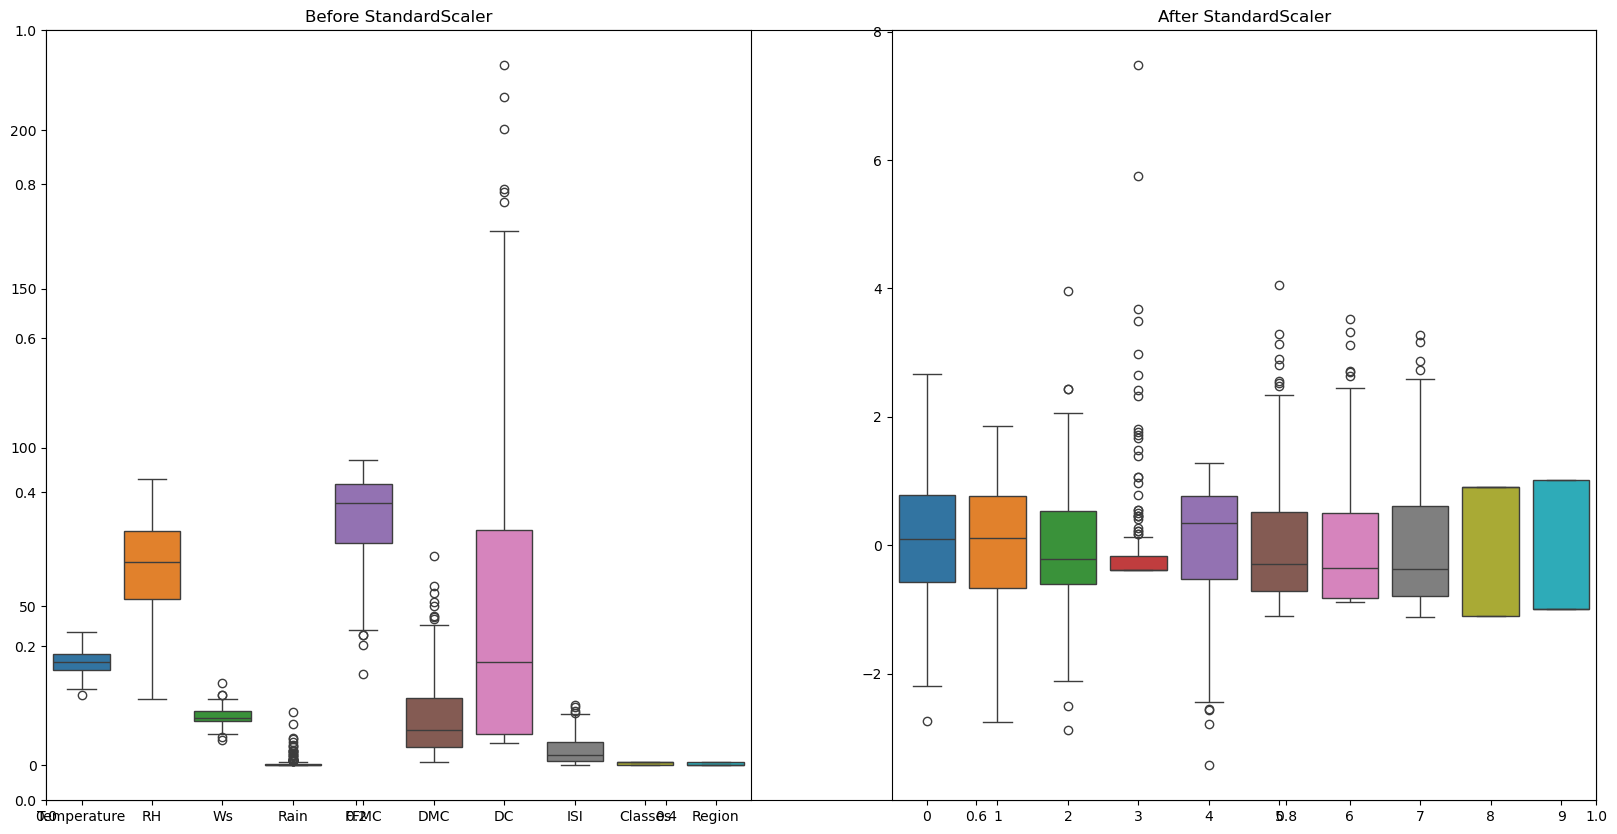

In [11]:
#Box plot to understand StandardScaler
plt.subplots(figsize=(20,10))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("Before StandardScaler")
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("After StandardScaler")

In [12]:
#Model Training 
#Lineaar Regression 
lr = LinearRegression()
lr.fit(X_train_scaled,y_train)  

y_pred = lr.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred) 

r2 = r2_score(y_test,y_pred) 

print("MAE:",mae)
print("R2 Score:",r2) 

MAE: 0.5170107980662413
R2 Score: 0.9830565611009445


In [13]:
# Ridge
ridge = Ridge()
ridge.fit(X_train_scaled,y_train)  

y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred) 

r2 = r2_score(y_test,y_pred) 

print("MAE:",mae)
print("R2 Score:",r2) 

MAE: 0.5292519766274837
R2 Score: 0.9824051915524249


In [14]:
# lasso
lasso = Lasso()
lasso.fit(X_train_scaled,y_train)  

y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred) 

r2 = r2_score(y_test,y_pred) 

print("MAE:",mae)
print("R2 Score:",r2) 

MAE: 1.1257992990774726
R2 Score: 0.9498931628519822


In [15]:
# ElasticNet 
elasticnet = ElasticNet()
elasticnet.fit(X_train_scaled,y_train)  

y_pred = elasticnet.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred) 

r2 = r2_score(y_test,y_pred) 

print("MAE:",mae)
print("R2 Score:",r2) 

MAE: 1.7704255521425287
R2 Score: 0.8887824924177792
